<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Multivariate" data-toc-modified-id="Multivariate-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Multivariate</a></span></li><li><span><a href="#Univariate" data-toc-modified-id="Univariate-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Univariate</a></span></li></ul></div>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from statsmodels.tsa.stattools import ccf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [2]:
wdf = pd.read_csv('waterlevel_55116010.csv')
rdf = pd.read_csv('rainfall_11368.csv')

print(wdf)
print(rdf)

                       Timestamp  Value
0      2023-01-01 00:00:00+00:00  1.174
1      2023-01-01 00:15:00+00:00  1.172
2      2023-01-01 00:30:00+00:00  1.168
3      2023-01-01 00:45:00+00:00  1.166
4      2023-01-01 01:00:00+00:00  1.161
...                          ...    ...
70171  2024-12-31 22:45:00+00:00  0.595
70172  2024-12-31 23:00:00+00:00  0.594
70173  2024-12-31 23:15:00+00:00  0.591
70174  2024-12-31 23:30:00+00:00  0.589
70175  2024-12-31 23:45:00+00:00  0.587

[70176 rows x 2 columns]
                       Timestamp  Value
0      2023-01-01 00:00:00+00:00    0.2
1      2023-01-01 00:15:00+00:00    0.0
2      2023-01-01 00:30:00+00:00    0.0
3      2023-01-01 00:45:00+00:00    0.2
4      2023-01-01 01:00:00+00:00    0.2
...                          ...    ...
70171  2024-12-31 22:45:00+00:00    0.0
70172  2024-12-31 23:00:00+00:00    0.0
70173  2024-12-31 23:15:00+00:00    0.0
70174  2024-12-31 23:30:00+00:00    0.0
70175  2024-12-31 23:45:00+00:00    0.0

[70176 rows x

In [3]:
wdf['Timestamp'] = pd.to_datetime(wdf['Timestamp']).dt.tz_localize(None)
rdf['Timestamp'] = pd.to_datetime(rdf['Timestamp']).dt.tz_localize(None)

print(wdf)
print(rdf)

                Timestamp  Value
0     2023-01-01 00:00:00  1.174
1     2023-01-01 00:15:00  1.172
2     2023-01-01 00:30:00  1.168
3     2023-01-01 00:45:00  1.166
4     2023-01-01 01:00:00  1.161
...                   ...    ...
70171 2024-12-31 22:45:00  0.595
70172 2024-12-31 23:00:00  0.594
70173 2024-12-31 23:15:00  0.591
70174 2024-12-31 23:30:00  0.589
70175 2024-12-31 23:45:00  0.587

[70176 rows x 2 columns]
                Timestamp  Value
0     2023-01-01 00:00:00    0.2
1     2023-01-01 00:15:00    0.0
2     2023-01-01 00:30:00    0.0
3     2023-01-01 00:45:00    0.2
4     2023-01-01 01:00:00    0.2
...                   ...    ...
70171 2024-12-31 22:45:00    0.0
70172 2024-12-31 23:00:00    0.0
70173 2024-12-31 23:15:00    0.0
70174 2024-12-31 23:30:00    0.0
70175 2024-12-31 23:45:00    0.0

[70176 rows x 2 columns]


In [4]:
# Data count
print(f"Initial Water Level data points: {len(wdf)}")
print(f"Initial Rainfall data points: {len(rdf)}")

Initial Water Level data points: 70176
Initial Rainfall data points: 70176


In [5]:
# Check for missing values
print("Water level missing values:\n", wdf.isnull().sum())
print("\nRainfall missing values:\n", rdf.isnull().sum())

Water level missing values:
 Timestamp    0
Value        0
dtype: int64

Rainfall missing values:
 Timestamp    0
Value        0
dtype: int64


In [6]:
# Check for duplicates
wdf = wdf.drop_duplicates(subset=['Timestamp']).dropna()
rdf = rdf.drop_duplicates(subset=['Timestamp']).dropna()

print(f"Water Level after cleaning: {len(wdf)}")
print(f"Rainfall after cleaning: {len(rdf)}")

Water Level after cleaning: 70176
Rainfall after cleaning: 70176


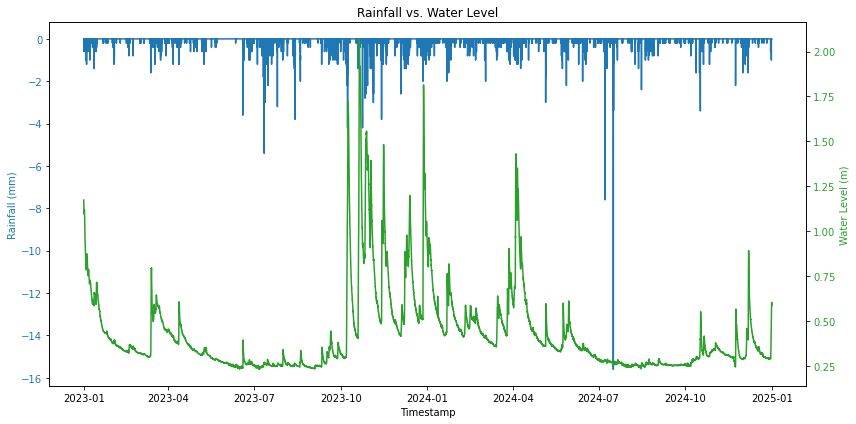

In [7]:
# Visualisation
plt.figure(figsize=(12, 6))

# Create primary axis
ax1 = plt.gca()
color = 'tab:blue'
ax1.set_xlabel('Timestamp')
ax1.set_ylabel('Rainfall (mm)', color=color)
ax1.plot(rdf['Timestamp'], -rdf['Value'], color=color, label='Rainfall')
ax1.tick_params(axis='y', labelcolor=color)

# Create secondary axis
ax2 = ax1.twinx()
color = 'tab:green'
ax2.set_ylabel('Water Level (m)', color=color)
ax2.plot(wdf['Timestamp'], wdf['Value'], color=color, label='Water Level')
ax2.tick_params(axis='y', labelcolor=color)

# Add title and legend
plt.title('Rainfall vs. Water Level')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
#ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()

In [8]:
# Merge datasets
merged = pd.merge_asof(wdf.sort_values('Timestamp'), 
                      rdf.sort_values('Timestamp'), 
                      on='Timestamp',
                      direction='nearest',
                      tolerance=pd.Timedelta('15min'))
merged = merged.rename(columns={'Value_x': 'WaterLevel', 'Value_y': 'Rainfall'})
print(merged)

                Timestamp  WaterLevel  Rainfall
0     2023-01-01 00:00:00       1.174       0.2
1     2023-01-01 00:15:00       1.172       0.0
2     2023-01-01 00:30:00       1.168       0.0
3     2023-01-01 00:45:00       1.166       0.2
4     2023-01-01 01:00:00       1.161       0.2
...                   ...         ...       ...
70171 2024-12-31 22:45:00       0.595       0.0
70172 2024-12-31 23:00:00       0.594       0.0
70173 2024-12-31 23:15:00       0.591       0.0
70174 2024-12-31 23:30:00       0.589       0.0
70175 2024-12-31 23:45:00       0.587       0.0

[70176 rows x 3 columns]


In [9]:
# Correlation
corr, p_value = pearsonr(merged['WaterLevel'], merged['Rainfall'])
print(f"Pearson correlation: {corr:.3f} (p-value: {p_value:.3f})")

if abs(corr) < 0.3:
    print("Low correlation - suggesting time lag effects")

Pearson correlation: 0.087 (p-value: 0.000)
Low correlation - suggesting time lag effects


A Pearson correlation of 0.087 at zero lag is very low.

This means that instantaneous rainfall and instantaneous water level do not have a strong linear relationship at the same timestamp.

However, the p‑value (0.000) shows the correlation is statistically significant — but the strength is still weak.

In [10]:
x = merged['Rainfall'].values
y = merged['WaterLevel'].values

# Normalise
x = (x - np.mean(x)) / np.std(x)
y = (y - np.mean(y)) / np.std(y)

# Full cross-correlation
corrs = np.correlate(y, x, mode='full')
lags = np.arange(-len(x)+1, len(x))

# Find lag with maximum correlation
best_lag = lags[np.argmax(corrs)]
print(f"Max correlation at lag = {best_lag} samples")

# Convert lag to time
time_step = pd.to_timedelta('15min')
time_lag = best_lag * time_step
print(f"Time lag = {time_lag}")

Max correlation at lag = 71 samples
Time lag = 0 days 17:45:00


71 samples × 15 minutes = 1065 minutes = 17 hours 45 minutes <br>
The rainfall signal leads the water level signal by approximately 17 hours 45 minutes.
In other words, rainfall today tends to have the strongest impact on water level about 17 hours 45 minutes later.<br>
<br>
Rainfall infiltrates soil, generates surface runoff, travels through drainage networks, and finally affects the monitored water level.

This delay can vary depending on catchment size, soil saturation, terrain, and channel routing.

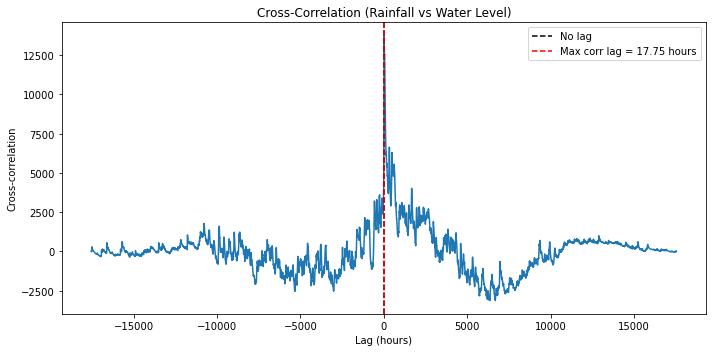

In [11]:
lags_hours = lags * (15/60)  # 15 minutes per sample
plt.figure(figsize=(10,5))
plt.plot(lags_hours, corrs)
plt.axvline(x=0, color='k', linestyle='--', label='No lag')
plt.axvline(x=best_lag*(15/60), color='r', linestyle='--', 
            label=f'Max corr lag = {best_lag*(15/60):.2f} hours')
plt.xlabel('Lag (hours)')
plt.ylabel('Cross-correlation')
plt.title('Cross-Correlation (Rainfall vs Water Level)')
plt.legend()
plt.tight_layout()
plt.show()

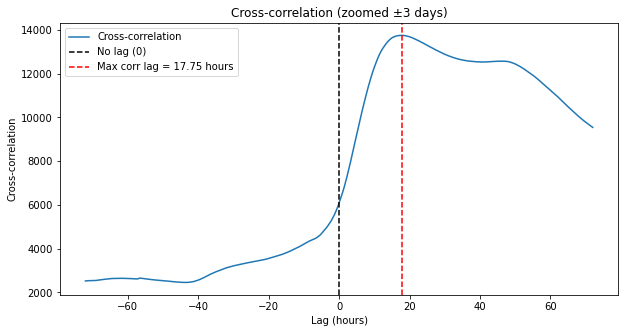

In [12]:
# Suppose you only care about ±3 days = 3*24 hours
max_hours = 3*24
mask = (lags_hours >= -max_hours) & (lags_hours <= max_hours)

plt.figure(figsize=(10,5))
plt.plot(lags_hours[mask], corrs[mask], label='Cross-correlation')
plt.axvline(x=0, color='k', linestyle='--', label='No lag (0)')
plt.axvline(x=best_lag*(15/60), color='r', linestyle='--', label=f'Max corr lag = {best_lag*(15/60):.2f} hours')
plt.xlabel('Lag (hours)')
plt.ylabel('Cross-correlation')
plt.title('Cross-correlation (zoomed ±3 days)')
plt.legend(loc='best')
plt.show()

# Multivariate
Input(X): rainfall + water level <br>
Output(Y): water level

In [13]:
# Split train / validation / test BEFORE scaling
train_ratio = 0.7
val_ratio   = 0.15
test_ratio  = 0.15

n = len(merged)
train_end = int(n * train_ratio)
val_end   = int(n * (train_ratio + val_ratio))

train_raw = merged[['Rainfall','WaterLevel']].iloc[:train_end]
val_raw   = merged[['Rainfall','WaterLevel']].iloc[train_end:val_end]
test_raw  = merged[['Rainfall','WaterLevel']].iloc[val_end:]

In [14]:
# Normalisation
scaler = MinMaxScaler()
scaler.fit(train_raw)

train_scaled = scaler.transform(train_raw)
val_scaled   = scaler.transform(val_raw)
test_scaled  = scaler.transform(test_raw)

In [15]:
columns = ['Rainfall', 'WaterLevel']
train_df = pd.DataFrame(train_scaled, columns=columns)
validation_df = pd.DataFrame(val_scaled, columns=columns)
test_df = pd.DataFrame(test_scaled, columns=columns)

# Calculate statistical properties for each dataset
stats_train = train_df.describe().loc[['mean', 'std', 'min', 'max']]
stats_validation = validation_df.describe().loc[['mean', 'std', 'min', 'max']]
stats_test = test_df.describe().loc[['mean', 'std', 'min', 'max']]

# Compare the statistics
print("Training Data Stats:\n", stats_train, "\n")
print("Validation Data Stats:\n", stats_validation, "\n")
print("Testing Data Stats:\n", stats_test, "\n")

Training Data Stats:
       Rainfall  WaterLevel
mean  0.005003    0.133124
std   0.025992    0.141550
min   0.000000    0.000000
max   1.000000    1.000000 

Validation Data Stats:
       Rainfall  WaterLevel
mean  0.003181    0.034386
std   0.036558    0.032442
min   0.000000    0.001633
max   2.888889    0.206859 

Testing Data Stats:
       Rainfall  WaterLevel
mean  0.003026    0.049153
std   0.021350    0.042152
min   0.000000    0.007621
max   0.629630    0.359281 



In [16]:
# Create sequences for LSTM
def create_sequences(data, past_steps=72, forecast_horizon=1):
    X, y = [], []
    for i in range(len(data) - past_steps - forecast_horizon + 1):
        X.append(data[i : i + past_steps, :])                                      # past [Rainfall, WaterLevel]
        y.append(data[i + past_steps : i + past_steps + forecast_horizon, 1][-1])  # future WaterLevel
    return np.array(X), np.array(y)

past_steps = 72          # 72 × 15 min = 1080 min = 18 hours
forecast_horizon = 1     # predict next step
X_train, y_train = create_sequences(train_scaled, past_steps, forecast_horizon)
X_val,   y_val   = create_sequences(val_scaled, past_steps, forecast_horizon)
X_test,  y_test  = create_sequences(test_scaled, past_steps, forecast_horizon)

print("Train:", X_train.shape, y_train.shape)
print("Val:  ", X_val.shape,   y_val.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (49051, 72, 2) (49051,)
Val:   (10454, 72, 2) (10454,)
Test:  (10455, 72, 2) (10455,)


In [17]:
# Build LSTM model
n_features = X_train.shape[2]

model = Sequential()
model.add(LSTM(64, input_shape=(past_steps, n_features)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',    # watch validation loss
    patience=10,           # stop if no improvement for 10 epochs
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
767/767 [==============================] - 31s 38ms/step - loss: 3.6049e-04 - val_loss: 3.7445e-06
Epoch 2/200
767/767 [==============================] - 30s 39ms/step - loss: 1.1928e-05 - val_loss: 3.5961e-06
Epoch 3/200
767/767 [==============================] - 31s 40ms/step - loss: 8.8755e-06 - val_loss: 2.4676e-06
Epoch 4/200
767/767 [==============================] - 30s 40ms/step - loss: 6.3781e-06 - val_loss: 1.8951e-06
Epoch 5/200
767/767 [==============================] - 31s 41ms/step - loss: 5.8026e-06 - val_loss: 2.2142e-06
Epoch 6/200
767/767 [==============================] - 34s 45ms/step - loss: 4.4213e-06 - val_loss: 9.1559e-07
Epoch 7/200
767/767 [==============================] - 33s 43ms/step - loss: 4.2516e-06 - val_loss: 1.0712e-06
Epoch 8/200
767/767 [==============================] - 34s 44ms/step - loss: 3.2960e-06 - val_loss: 1.0275e-06
Epoch 9/200
767/767 [==============================] - 36s 46ms/step - loss: 2.9272e-06 - val_loss: 1.6878e-06
E

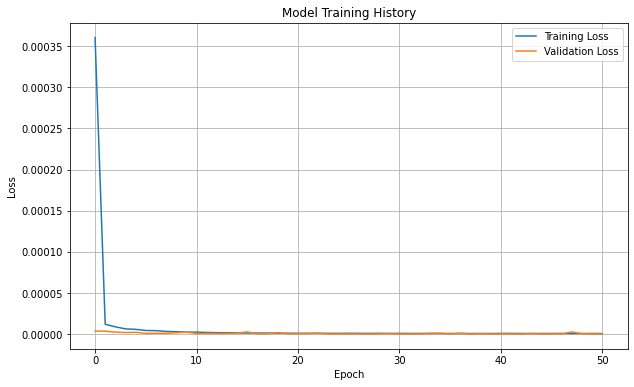

In [18]:
# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [19]:
y_pred_scaled = model.predict(X_test)

# Inverse-transform predictions
temp_pred = np.zeros((len(y_pred_scaled), 2))
temp_pred[:, 1] = y_pred_scaled[:, 0]
y_pred = scaler.inverse_transform(temp_pred)[:, 1]

temp_true = np.zeros((len(y_test), 2))
temp_true[:, 1] = y_test
y_true = scaler.inverse_transform(temp_true)[:, 1]

327/327 [==============================] - 6s 14ms/step


In [20]:
def plot_predictions_with_error(true_data, predicted_data, rainfall_data, title):
    plt.figure(figsize=(14, 6))
    
    true_data_flatten = true_data.flatten()
    predicted_data_flatten = predicted_data.flatten()
    rainfall_flatten = rainfall_data.flatten()
    
    error = true_data_flatten - predicted_data_flatten
    residuals_std = np.std(error)
    
    # --- Left subplot: water level + inverted rainfall ---
    ax1 = plt.subplot(1, 2, 1)
    
    # Plot true and predicted water level on primary y-axis
    line1, = ax1.plot(true_data_flatten, label='True Water Level', color='#1f77b4', linewidth=2)
    line2, = ax1.plot(predicted_data_flatten, label='Predicted Water Level', color='#ff7f0e', alpha=0.7, linestyle='--', linewidth=1.5)
    ax1.set_xlabel('Time Step')
    ax1.set_ylabel('Water Level')
    ax1.set_title(title)
    ax1.grid(True, linestyle=':', alpha=0.7)
    
    # Create secondary y-axis for rainfall
    ax2 = ax1.twinx()
    line3, = ax2.plot(-rainfall_flatten, label='Inverted Rainfall', color='tab:blue', alpha=0.5)
    ax2.set_ylabel('Rainfall (inverted)')
    
    # Combine legends from ax1 and ax2 into one legend box on ax1
    lines = [line1, line2, line3]
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='upper left', bbox_to_anchor=(0, 0.9))
    
    # --- Second subplot: residuals ---
    ax3 = plt.subplot(1, 2, 2)
    ax3.scatter(predicted_data_flatten, error, alpha=0.5, label='Residuals')
    ax3.axhline(0, color='red', linestyle='--', label='Zero Error')
    ax3.set_xlabel('Predicted Water Level')
    ax3.set_ylabel('Residuals (True - Predicted)')
    ax3.set_title(f'Residual Plot (Std: {residuals_std:.3f})')
    ax3.legend(loc='upper right')
    ax3.grid(True, linestyle=':', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

In [21]:
train_pred = model.predict(X_train)
validation_pred = model.predict(X_val)
test_pred = model.predict(X_test)

327/327 [==============================] - 5s 14ms/step


In [22]:
rainfall_train = x[:len(y_train)]
rainfall_val = x[len(y_train):len(y_train) + len(y_val)]
rainfall_test = x[len(y_train) + len(y_val):len(y_train) + len(y_val) + len(y_test)]

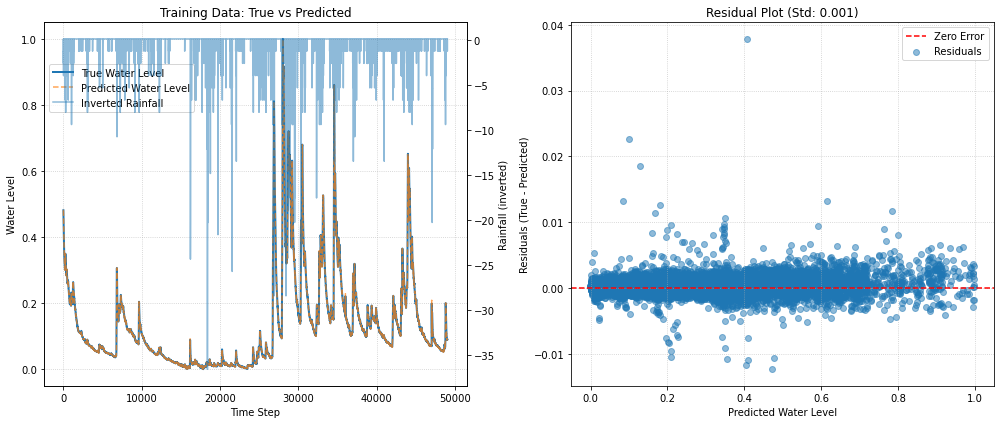

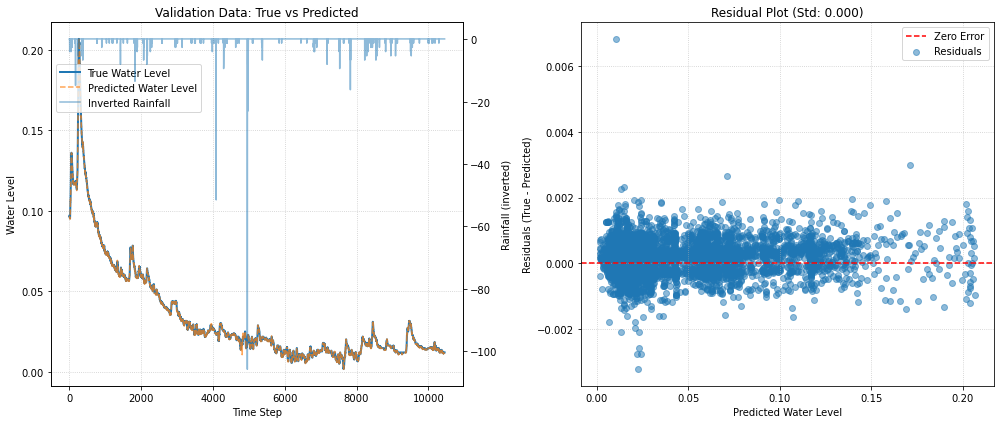

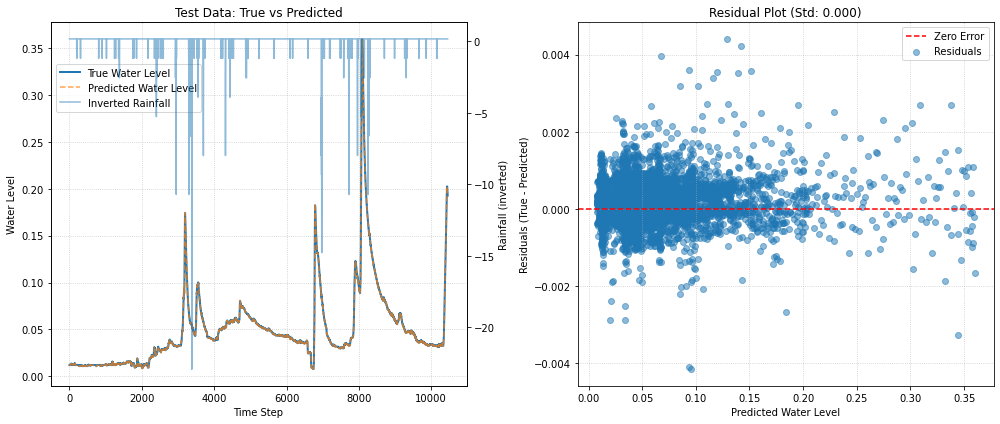

In [23]:
plot_predictions_with_error(y_train, train_pred, rainfall_train, 'Training Data: True vs Predicted')
plot_predictions_with_error(y_val, validation_pred, rainfall_val, 'Validation Data: True vs Predicted')
plot_predictions_with_error(y_test, test_pred, rainfall_test, 'Test Data: True vs Predicted')

In [24]:
# Compute fit stats
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

R²: 1.000
RMSE: 0.001
MAE: 0.001


# Univariate
Input(X): rainfall <br>
Output(Y): water level

In [25]:
# Train/Validation/Test split
train_size = int(len(merged) * 0.7)
val_size   = int(len(merged) * 0.15)

train_data = merged.iloc[:train_size]
val_data   = merged.iloc[train_size:train_size + val_size]
test_data  = merged.iloc[train_size + val_size:]

In [26]:
scaler_rain = MinMaxScaler()
scaler_level = MinMaxScaler()

# Fit scalers on training set only
scaler_rain.fit(train_data[['Rainfall']])
scaler_level.fit(train_data[['WaterLevel']])

rain_train  = scaler_rain.transform(train_data[['Rainfall']]).flatten()
rain_val    = scaler_rain.transform(val_data[['Rainfall']]).flatten()
rain_test   = scaler_rain.transform(test_data[['Rainfall']]).flatten()

level_train = scaler_level.transform(train_data[['WaterLevel']]).flatten()
level_val   = scaler_level.transform(val_data[['WaterLevel']]).flatten()
level_test  = scaler_level.transform(test_data[['WaterLevel']]).flatten()

In [27]:
# Create sequences
def create_sequences_univariate(input_series, target_series, past_steps=72, forecast_horizon=1):
    X, y = [], []
    for i in range(len(input_series) - past_steps - forecast_horizon + 1):
        X.append(input_series[i : i + past_steps])  # past rainfall only
        y.append(target_series[i + past_steps : i + past_steps + forecast_horizon][-1])  # future water level
    return np.array(X), np.array(y)

past_steps = 72  # based on lag analysis (≈18 hours)
forecast_horizon = 1

X_train, y_train = create_sequences_univariate(rain_train, level_train, past_steps, forecast_horizon)
X_val, y_val = create_sequences_univariate(rain_val, level_val, past_steps, forecast_horizon)
X_test, y_test = create_sequences_univariate(rain_test, level_test, past_steps, forecast_horizon)

# Reshape X for LSTM: (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_val   = X_val.reshape((X_val.shape[0], X_val.shape[1], 1))
X_test  = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (49051, 72, 1) (49051,)
Val: (10454, 72, 1) (10454,)
Test: (10455, 72, 1) (10455,)


In [28]:
model_uni = Sequential()
model_uni.add(LSTM(64, input_shape=(past_steps, 1)))  # 1 feature now
model_uni.add(Dense(1))
model_uni.compile(optimizer='adam', loss='mse')

early_stop = EarlyStopping(
    monitor='val_loss',    # watch validation loss
    patience=10,           # stop if no improvement for 10 epochs
    restore_best_weights=True
)

history_uni = model_uni.fit(
    X_train, y_train,
    epochs=200,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/200
767/767 [==============================] - 38s 47ms/step - loss: 0.0172 - val_loss: 0.0139
Epoch 2/200
767/767 [==============================] - 37s 48ms/step - loss: 0.0166 - val_loss: 0.0111
Epoch 3/200
767/767 [==============================] - 36s 47ms/step - loss: 0.0165 - val_loss: 0.0093
Epoch 4/200
767/767 [==============================] - 35s 46ms/step - loss: 0.0165 - val_loss: 0.0099
Epoch 5/200
767/767 [==============================] - 38s 49ms/step - loss: 0.0164 - val_loss: 0.0111
Epoch 6/200
767/767 [==============================] - 39s 50ms/step - loss: 0.0162 - val_loss: 0.0082
Epoch 7/200
767/767 [==============================] - 37s 49ms/step - loss: 0.0161 - val_loss: 0.0105
Epoch 8/200
767/767 [==============================] - 37s 48ms/step - loss: 0.0160 - val_loss: 0.0083
Epoch 9/200
767/767 [==============================] - 39s 51ms/step - loss: 0.0160 - val_loss: 0.0110
Epoch 10/200
767/767 [==============================] - 42s 54ms/step - l

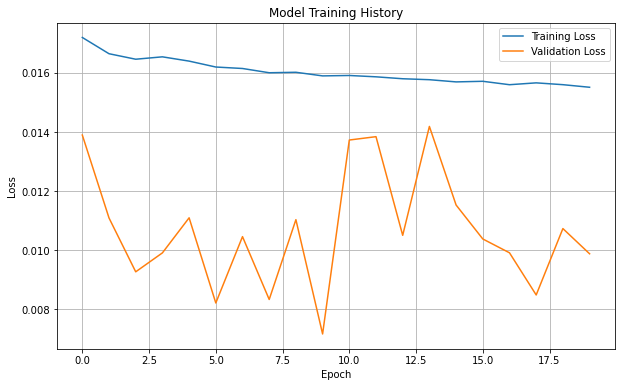

In [33]:
# Plot the training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history_uni.history['loss'], label='Training Loss')
plt.plot(history_uni.history['val_loss'], label='Validation Loss')
plt.title('Model Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

In [30]:
y_pred_scaled = model_uni.predict(X_test)

# inverse-transform predictions
y_pred = scaler_level.inverse_transform(y_pred_scaled)
y_true = scaler_level.inverse_transform(y_test.reshape(-1,1))

327/327 [==============================] - 4s 12ms/step


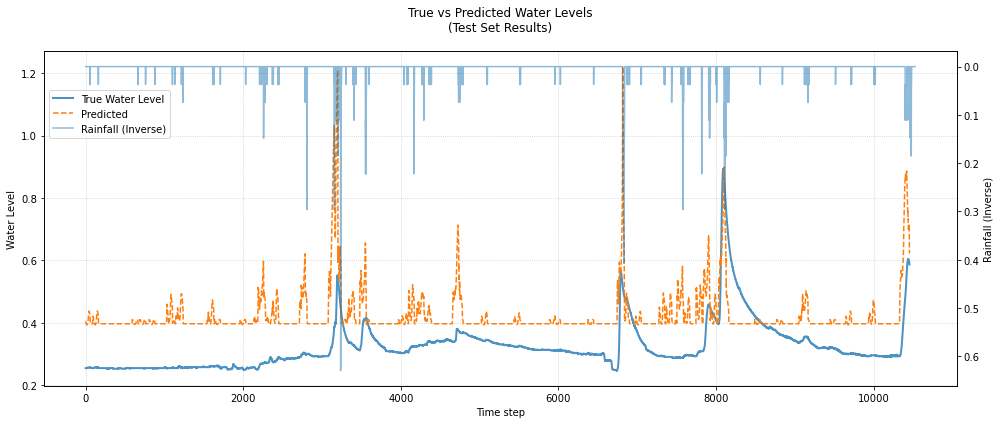

In [31]:
# Inverse-transform predictions and true values
y_pred = scaler_level.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()
y_true = scaler_level.inverse_transform(y_test.reshape(-1, 1)).flatten()

rain_test_reshaped = rain_test.reshape(-1, 1)

# Plot settings
fig, ax1 = plt.subplots(figsize=(14, 6))
ax1.plot(y_true, label='True Water Level', color='#1f77b4', linewidth=2, alpha=0.8)
ax1.plot(y_pred, label='Predicted', color='#ff7f0e', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Time step')
ax1.set_ylabel('Water Level')
ax1.grid(True, linestyle=':', alpha=0.7)

ax2 = ax1.twinx()
ax2.plot(rain_test_reshaped, label='Rainfall (Inverse)', color='tab:blue', alpha=0.5)
ax2.set_ylabel('Rainfall (Inverse)')
ax2.invert_yaxis()  # invert y-axis for rainfall

# Combine legends
lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, fontsize=10, loc='upper left', bbox_to_anchor=(0, 0.9))

plt.title('True vs Predicted Water Levels\n(Test Set Results)', pad=20)
plt.tight_layout()

In [32]:
# Compute fit stats
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
mae = mean_absolute_error(y_true, y_pred)

print(f"R²: {r2:.3f}")
print(f"RMSE: {rmse:.3f}")
print(f"MAE: {mae:.3f}")

R²: -1.804
RMSE: 0.130
MAE: 0.112


The LSTM model yielded an RMSE of 0.136 and an MAE of 0.125.
However, the coefficient of determination (R²) was -2.082, indicating that the model performs worse than a baseline model that predicts the mean water level.
This suggests that the current model configuration (e.g., input features, past window size, or hyperparameters) is not adequately capturing the relationship between rainfall and water level.